# IoT Sensor Fault Detector — EDA + Model Training

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('ai4i2020.csv')
df.shape

(10000, 14)

In [2]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 10000 entries, 0 to 9999
Data columns (total 14 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   UDI                      10000 non-null  int64  
 1   Product ID               10000 non-null  str    
 2   Type                     10000 non-null  str    
 3   Air temperature [K]      10000 non-null  float64
 4   Process temperature [K]  10000 non-null  float64
 5   Rotational speed [rpm]   10000 non-null  int64  
 6   Torque [Nm]              10000 non-null  float64
 7   Tool wear [min]          10000 non-null  int64  
 8   Machine failure          10000 non-null  int64  
 9   TWF                      10000 non-null  int64  
 10  HDF                      10000 non-null  int64  
 11  PWF                      10000 non-null  int64  
 12  OSF                      10000 non-null  int64  
 13  RNF                      10000 non-null  int64  
dtypes: float64(3), int64(9), str(2)
me

In [3]:
df.describe()

,UDI,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
count,10000.00000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.000000,10000.00000
mean,5000.50000,300.004930,310.005560,1538.776100,39.986910,107.951000,0.033900,0.004600,0.011500,0.009500,0.009800,0.00190
std,2886.89568,2.000259,1.483734,179.284096,9.968934,63.654147,0.180981,0.067671,0.106625,0.097009,0.098514,0.04355
min,1.00000,295.300000,305.700000,1168.000000,3.800000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
25%,2500.75000,298.300000,308.800000,1423.000000,33.200000,53.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
50%,5000.50000,300.100000,310.100000,1503.000000,40.100000,108.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
75%,7500.25000,301.500000,311.100000,1612.000000,46.800000,162.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000
max,10000.00000,304.500000,313.800000,2886.000000,76.600000,253.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.00000


In [4]:
df.duplicated().sum()

np.int64(0)

## Target distribution

In [5]:
df['Machine failure'].value_counts()

Machine failure
0    9661
1     339
Name: count, dtype: int64

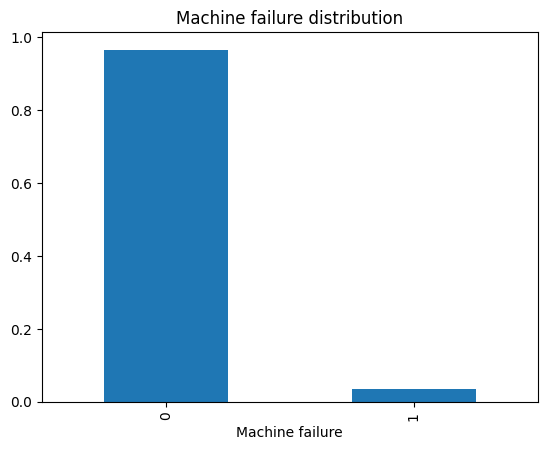

In [6]:
df['Machine failure'].value_counts(normalize=True).plot(kind='bar')
plt.title('Machine failure distribution')
plt.show()

## Feature distributions

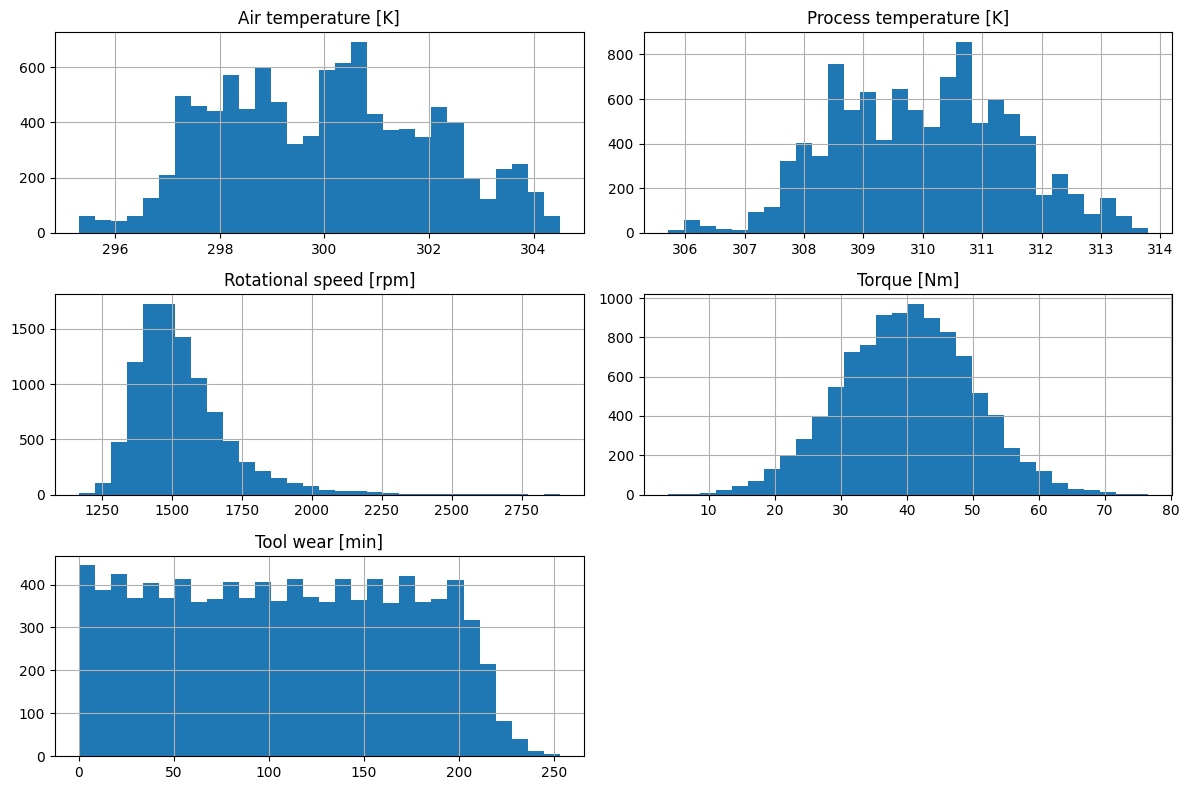

In [7]:
num_cols = ['Air temperature [K]', 'Process temperature [K]',
            'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]']

df[num_cols].hist(figsize=(12, 8), bins=30)
plt.tight_layout()
plt.show()

## Feature vs target

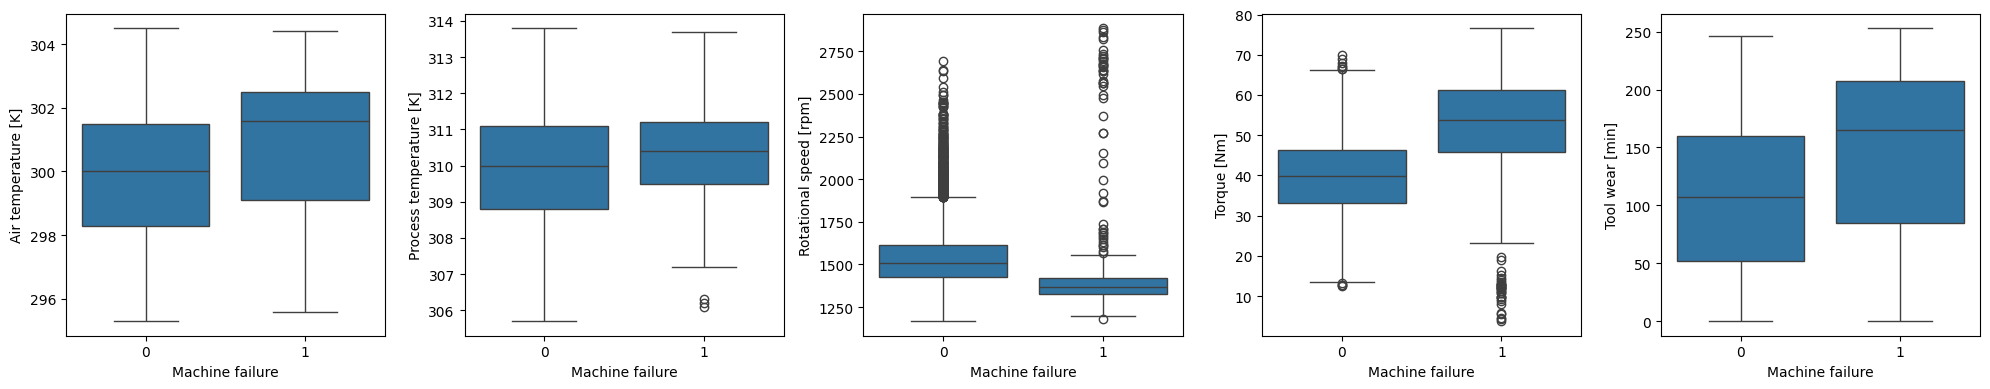

In [8]:
fig, axes = plt.subplots(1, 5, figsize=(20, 4))
for ax, col in zip(axes, num_cols):
    sns.boxplot(x='Machine failure', y=col, data=df, ax=ax)
plt.tight_layout()
plt.show()

In [9]:
pd.crosstab(df['Type'], df['Machine failure'], normalize='index')

Machine failure,0,1
Type,,
H,0.979063,0.020937
L,0.960833,0.039167
M,0.972306,0.027694


## Correlation

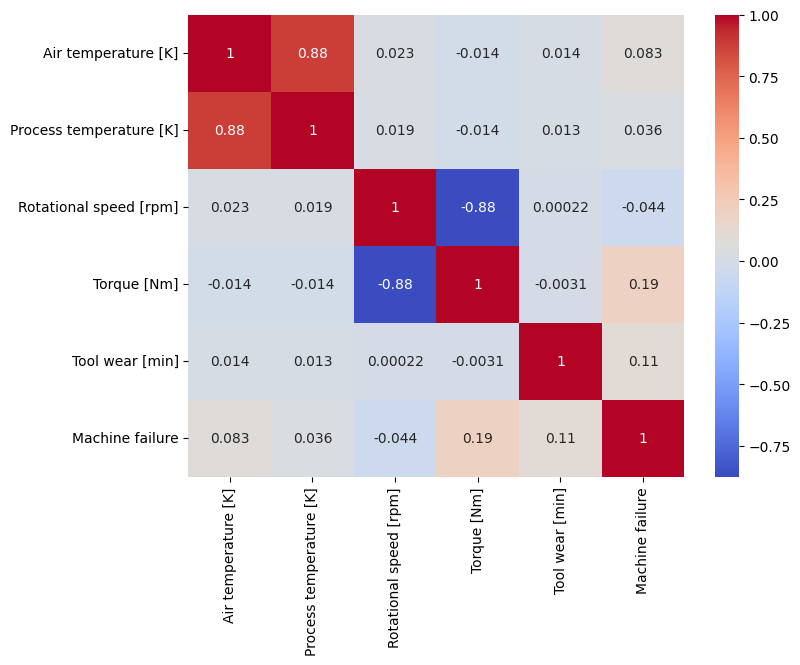

In [10]:
plt.figure(figsize=(8, 6))
sns.heatmap(df[num_cols + ['Machine failure']].corr(), annot=True, cmap='coolwarm')
plt.show()

## Failure mode breakdown (not used as features — would leak the target)

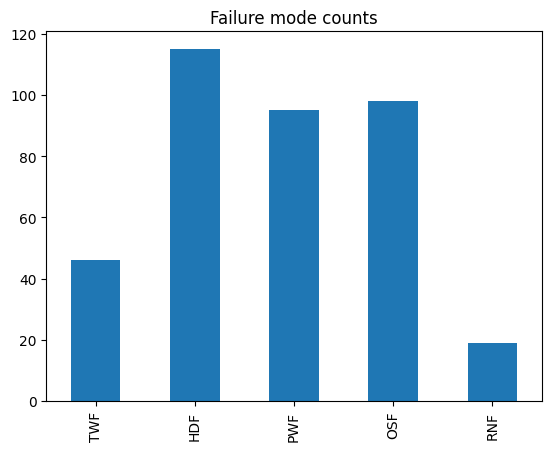

In [11]:
df[['TWF', 'HDF', 'PWF', 'OSF', 'RNF']].sum().plot(kind='bar')
plt.title('Failure mode counts')
plt.show()

## Prep data for modeling

In [12]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder

data = df.drop(columns=['UDI', 'Product ID', 'TWF', 'HDF', 'PWF', 'OSF', 'RNF'])

le = LabelEncoder()
data['Type'] = le.fit_transform(data['Type'])

X = data.drop(columns=['Machine failure'])
y = data['Machine failure']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

X_train.shape, X_test.shape

((8000, 6), (2000, 6))

## Baseline model — RandomForest (class_weight balanced for imbalance)

In [13]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, ConfusionMatrixDisplay

model = RandomForestClassifier(
    n_estimators=200,
    class_weight='balanced',
    random_state=42
)
model.fit(X_train, y_train)

y_pred = model.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.98      1.00      0.99      1932
           1       0.88      0.53      0.66        68

    accuracy                           0.98      2000
   macro avg       0.93      0.76      0.83      2000
weighted avg       0.98      0.98      0.98      2000



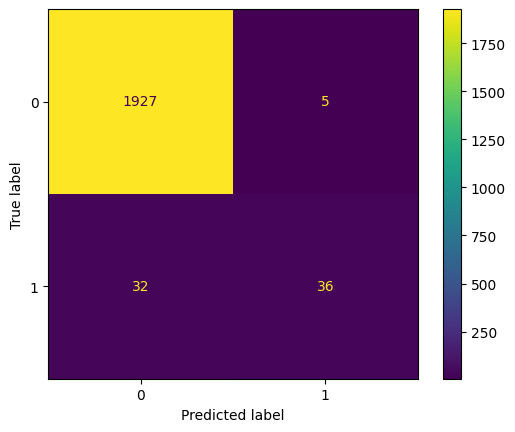

In [14]:
ConfusionMatrixDisplay.from_predictions(y_test, y_pred)
plt.show()

## Feature importance

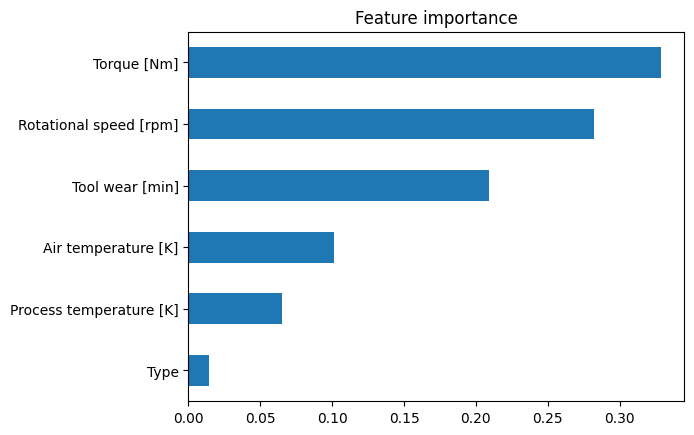

In [15]:
importances = pd.Series(model.feature_importances_, index=X.columns).sort_values()
importances.plot(kind='barh')
plt.title('Feature importance')
plt.show()

## Save model (baseline, before quantization/pruning)

In [16]:
import joblib
joblib.dump(model, 'fault_detector_baseline.pkl')

['fault_detector_baseline.pkl']

## Takeaways
- Machine failure rate: ~3.4% — significant class imbalance, handled with `class_weight='balanced'`
- Tool wear, torque, and rotational speed carry more signal than air/process temperature
- Baseline model saved for the next step: quantization/pruning for constrained deployment